# Лабораторная работа 2. Обучение с учителем. Задача регрессии

## Задача регрессии

### Загрузка данных

In [115]:
import pandas as pd

In [116]:
data = pd.read_csv('../datasets/filtered_moldova_cars_task.csv')
data

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Price(euro),Vehicle_age,Avg_mileage
0,0.102058,0.011583,2011,0.186425,195000,1800,0.054398,0.381082,7750,15,13000
1,0.084965,0.012745,2014,0.206439,135000,1500,0.466976,0.618918,8550,12,11250
2,0.118254,0.027315,1998,0.186425,1,1400,0.358679,0.618918,2200,28,0
3,0.084965,0.004016,2012,0.206439,110000,1500,0.466976,0.618918,6550,14,7857
4,0.067707,0.030501,2006,0.206439,200000,1600,0.107202,0.618918,4100,20,10000
...,...,...,...,...,...,...,...,...,...,...,...
30125,0.005012,0.002622,2002,0.110289,225000,1800,0.107202,0.618918,4400,24,9375
30126,0.048623,0.017126,2015,0.206439,89000,1500,0.466976,0.618918,7000,11,8091
30127,0.084965,0.000431,2009,0.186425,225,1500,0.466976,0.618918,4500,17,13
30128,0.015500,0.002987,2006,0.011650,370000,2000,0.466976,0.618918,4000,20,18500


### Первый шаг: выделение целевого признака и предикторов

In [117]:
y = data["Price(euro)"]
X = data.drop(["Price(euro)"], axis=1)

In [118]:
y

0        7750
1        8550
2        2200
3        6550
4        4100
         ... 
30125    4400
30126    7000
30127    4500
30128    4000
30129    4000
Name: Price(euro), Length: 30130, dtype: int64

In [119]:
X

,Make,Model,Year,Style,Distance,Engine_capacity(cm3),Fuel_type,Transmission,Vehicle_age,Avg_mileage
0,0.102058,0.011583,2011,0.186425,195000,1800,0.054398,0.381082,15,13000
1,0.084965,0.012745,2014,0.206439,135000,1500,0.466976,0.618918,12,11250
2,0.118254,0.027315,1998,0.186425,1,1400,0.358679,0.618918,28,0
3,0.084965,0.004016,2012,0.206439,110000,1500,0.466976,0.618918,14,7857
4,0.067707,0.030501,2006,0.206439,200000,1600,0.107202,0.618918,20,10000
...,...,...,...,...,...,...,...,...,...,...
30125,0.005012,0.002622,2002,0.110289,225000,1800,0.107202,0.618918,24,9375
30126,0.048623,0.017126,2015,0.206439,89000,1500,0.466976,0.618918,11,8091
30127,0.084965,0.000431,2009,0.186425,225,1500,0.466976,0.618918,17,13
30128,0.015500,0.002987,2006,0.011650,370000,2000,0.466976,0.618918,20,18500


### Разбиение на обучающую и тестовую выборки

In [120]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [121]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((24104, 10), (24104,), (6026, 10), (6026,))

### Линейная регрессия в sklearn (+ регуляризации и использование полиномов)

In [122]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from math import sqrt

In [123]:
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)


In [124]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred)}')
print(f'R^2: {r2_score(y_test, y_pred)}')
lr.coef_

MAE: 2259.2670400994753
MSE: 9444594.993930863
RMSE: 3073.2059797434445
MAPE: 0.833239718389108
R^2: 0.657109514391212


array([-1.30994575e+03,  7.87670413e+03,  1.92467415e+02, -1.90466455e+03,
       -1.53983483e-02,  4.14942136e+00,  3.05160760e+02, -9.92510465e+03,
       -1.92467415e+02,  2.51482468e-01])

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

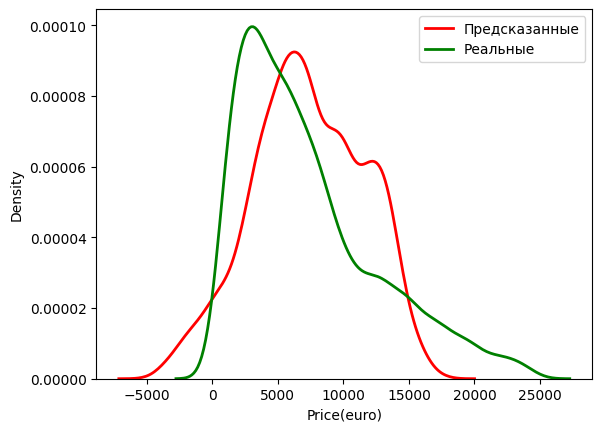

In [126]:
sns.kdeplot(y_pred, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [127]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [128]:
# L1
lasso = Lasso(alpha=0.5, max_iter=50000).fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)
print(f'MAE: {mean_absolute_error(y_test, y_pred_lasso)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_lasso)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_lasso))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_lasso)}')
print(f'R^2: {r2_score(y_test, y_pred_lasso)}')
lasso.coef_

MAE: 2259.2831643782233
MSE: 9444622.188697986
RMSE: 3073.210404234957
MAPE: 0.8331763724010098
R^2: 0.6571085270723369


array([  -44.25216961,    79.70894762,  2599.20931814,  -158.58657203,
       -1484.33870076,  1527.14189049,    41.49485067, -1145.88644519,
          -0.        ,  1368.76322041])

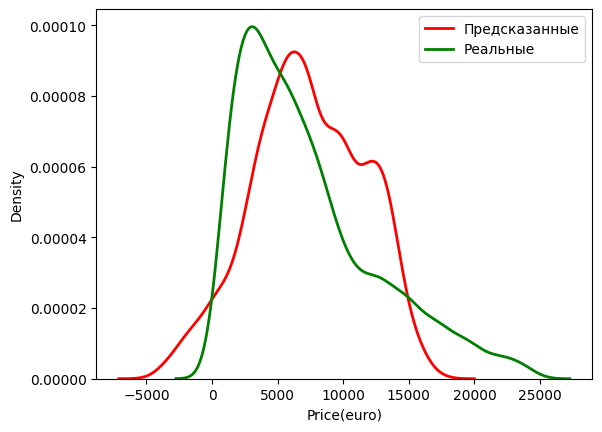

In [129]:
sns.kdeplot(y_pred_lasso, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [130]:
# L2
ridge = Ridge(alpha=0.5, max_iter=50000).fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)
print(f'MAE: {mean_absolute_error(y_test, y_pred_ridge)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_ridge)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_ridge))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_ridge)}')
print(f'R^2: {r2_score(y_test, y_pred_ridge)}')
ridge.coef_

MAE: 2259.2678016317172
MSE: 9444602.379272208
RMSE: 3073.207181312742
MAPE: 0.8332349922923133
R^2: 0.6571092462629036


array([  -45.22058874,    80.85213911,  1298.46437271,  -159.25093139,
       -1489.17217996,  1527.66978452,    41.82204213, -1146.13344169,
       -1298.46437271,  1373.52552839])

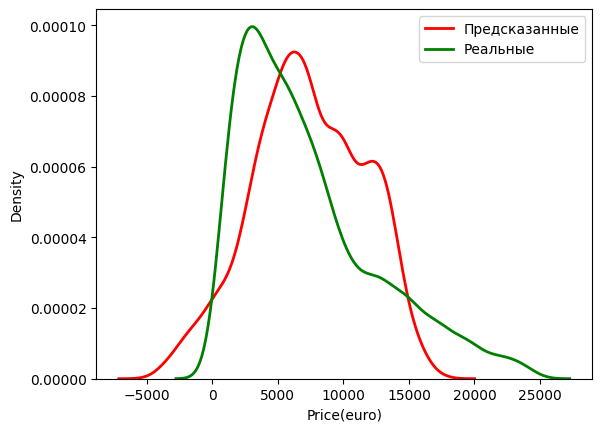

In [131]:
sns.kdeplot(y_pred_ridge, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [132]:
el = ElasticNet(alpha=0.5, max_iter=50000).fit(X_train_scaled, y_train)
y_pred_el = el.predict(X_test_scaled)
print(f'MAE: {mean_absolute_error(y_test, y_pred_el)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_el)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_el))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_el)}')
print(f'R^2: {r2_score(y_test, y_pred_el)}')
el.coef_

MAE: 2297.301632721122
MSE: 9788716.318006989
RMSE: 3128.6924294354963
MAPE: 0.7369903350308245
R^2: 0.6446160270583379


array([  -42.09178216,    40.8036358 ,  1337.2165363 ,  -168.54972641,
        -632.61437025,  1166.75610261,    41.46455681, -1129.88543521,
       -1337.12973621,   562.68539305])

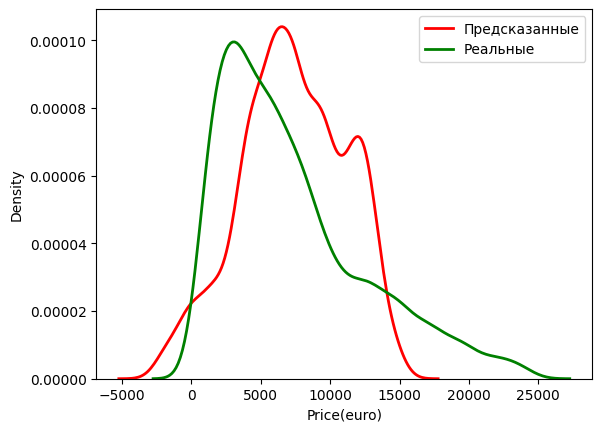

In [133]:
sns.kdeplot(y_pred_el, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

In [134]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_p = poly.fit_transform(X_train_scaled)
X_test_p = poly.transform(X_test_scaled)
lr2 = LinearRegression().fit(X_train_p, y_train)
y_pred_p = lr2.predict(X_test_p)
print(f'MAE: {mean_absolute_error(y_test, y_pred_p)}')
print(f'MSE: {mean_squared_error(y_test, y_pred_p)}')
print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred_p))}')
print(f'MAPE: {mean_absolute_percentage_error(y_test, y_pred_p)}')
print(f'R^2: {r2_score(y_test, y_pred_p)}')
lr2.coef_

MAE: 1713.5391624136823
MSE: 5872322.351111143
RMSE: 2423.2875089661034
MAPE: 0.6180630174773426
R^2: 0.7868025612619955


array([-1.41130526e+02,  3.55309854e+02,  1.19793356e+04, -1.50564024e+02,
        2.84781561e+04,  1.59276173e+03,  9.91833436e+01, -5.51228981e+02,
       -1.19793356e+04, -2.85118578e+04,  1.09976957e+02, -3.25819419e+02,
        4.01823464e+01, -6.52891645e+01,  3.33079979e+02, -8.61689837e+01,
       -3.08246841e+01,  1.19608410e+02, -4.01823464e+01, -3.29494882e+02,
       -2.94563051e+00,  1.09355932e+02,  2.31673338e+02,  6.36687052e+01,
       -1.49786989e+01, -5.04495525e+01,  2.89946376e+01, -1.09355932e+02,
       -5.14820257e+01,  4.01019878e+02, -9.65522172e+01,  2.20142351e+02,
        2.87342999e+02,  2.69305543e+01, -3.02337652e+02, -4.01019878e+02,
        5.29456954e+03,  6.01078179e+01, -2.32277642e+01, -3.70580831e+01,
        8.22330354e+01, -2.95639144e+01,  9.65522172e+01,  7.00554807e+01,
        3.78895012e+02, -4.99346932e+02, -2.95363513e+02,  4.52723864e+01,
       -2.20142351e+02, -5.57401412e+02, -1.12158606e+01,  8.87806262e+01,
       -1.47420355e+02, -

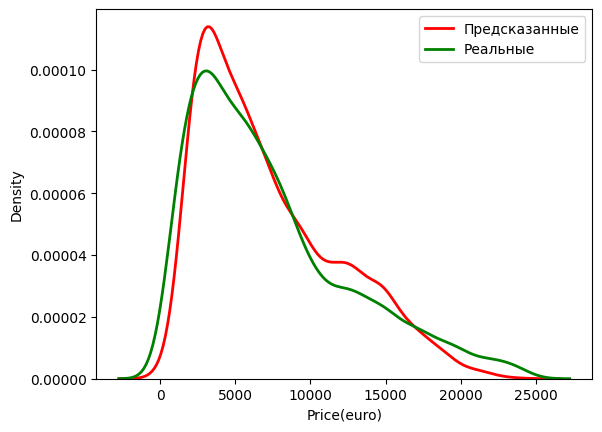

In [135]:
sns.kdeplot(y_pred_p, color='red', label='Предсказанные', linewidth=2)
sns.kdeplot(y_test, color='green', label='Реальные', linewidth=2)
plt.legend()
plt.show()

# Поиск оптимального гиперпараметра для моделей 

In [136]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np

In [137]:
parameters = {'alpha': np.arange(0.1, 10.1, 0.1)}

In [138]:
lasso_optimal = GridSearchCV(Lasso(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
lasso_optimal.best_params_

{'alpha': np.float64(0.2)}

In [139]:
lasso_optimal = RandomizedSearchCV(Lasso(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
lasso_optimal.best_params_

{'alpha': np.float64(0.6)}

In [140]:
ridge_optimal = GridSearchCV(Ridge(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(10.0)}

In [141]:
ridge_optimal = RandomizedSearchCV(Ridge(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
ridge_optimal.best_params_

{'alpha': np.float64(9.3)}

In [142]:
parameters = {'alpha': np.arange(0.1, 10.1, 0.1), 'l1_ratio': np.arange(0.1, 1.1, 0.1)}

In [143]:
el_optimal = GridSearchCV(ElasticNet(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
el_optimal.best_params_

{'alpha': np.float64(0.2), 'l1_ratio': np.float64(1.0)}

In [144]:
el_optimal = RandomizedSearchCV(ElasticNet(max_iter = 10000), parameters, cv=5).fit(X_train_scaled, y_train)
el_optimal.best_params_

{'l1_ratio': np.float64(1.0), 'alpha': np.float64(2.6)}

In [185]:
import optuna as pt

def optuna(model_name, X_train, y_train, X_test, y_test):
    def objective(trial):
        alpha = trial.suggest_float("alpha", 1e-5, 1e2)

        if model_name == 'lasso':
            model = Lasso(alpha=alpha)
        elif model_name == 'ridge':
            model = Ridge(alpha=alpha)
        elif model_name == 'elasticnet':
            l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio)

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        return mse
    
    # Настраиваем оптимизацию гиперпараметров
    study = pt.create_study(direction='minimize')
    study.optimize(objective, n_trials=100)

    # Выводим лучшие гиперпараметры
    best_params = study.best_params
    
    return best_params['alpha'] if model_name != 'elasticnet' else (best_params['alpha'], best_params['l1_ratio'])


In [186]:
models = ('lasso', 'ridge', 'elasticnet')
best_params = {}

for model in models:
    best_param = optuna(model, X_train=X_train_scaled, y_train=y_train, X_test=X_test_scaled, y_test=y_test)
    best_params[f'{model}_optuna'] = best_param

[I 2025-09-01 18:48:37,668] A new study created in memory with name: no-name-2e2fa4cb-1163-4fe0-b8a2-b052cc54f107
[I 2025-09-01 18:48:37,807] Trial 0 finished with value: 9610139.325892653 and parameters: {'alpha': 92.0186916421348}. Best is trial 0 with value: 9610139.325892653.
[I 2025-09-01 18:48:37,877] Trial 1 finished with value: 9563718.647347197 and parameters: {'alpha': 76.95731577834101}. Best is trial 1 with value: 9563718.647347197.
[I 2025-09-01 18:48:37,976] Trial 2 finished with value: 9473582.495972421 and parameters: {'alpha': 34.85900861639656}. Best is trial 2 with value: 9473582.495972421.
[I 2025-09-01 18:48:38,126] Trial 3 finished with value: 9445241.6663989 and parameters: {'alpha': 4.3994556286971696}. Best is trial 3 with value: 9445241.6663989.
[I 2025-09-01 18:48:38,148] Trial 4 finished with value: 9496154.615258407 and parameters: {'alpha': 47.82683199317015}. Best is trial 3 with value: 9445241.6663989.
[I 2025-09-01 18:48:38,169] Trial 5 finished with va

In [187]:
for model in models:
    print(f"Лучший параметр для {model}: {best_params[f'{model}_optuna']}")

Лучший параметр для lasso: 0.3028126505271961
Лучший параметр для ridge: 0.0011894117629990403
Лучший параметр для elasticnet: (0.00015942870865423564, 0.9768003936566219)


# Построение pipelines

Нам осталось разобраться с полиномиальной регрессией. Ее проще всего понять на одномерной регрессии (когда у нас один предиктор). Давайте создадим искусственный датасет, в котором у нас будет зарплата специалиста и его стаж. Мы хотим построить модель, которая будет предсказывать зарплату по стажу.

In [188]:
data2=pd.DataFrame({
    'Exp':[2,2.2, 2.8, 4, 7, 8, 11, 12, 21, 25],
    'Salary': [7, 8, 11, 15, 22, 29, 37 ,45.7, 49, 52]
})
data2

,Exp,Salary
0,2.0,7.0
1,2.2,8.0
2,2.8,11.0
3,4.0,15.0
4,7.0,22.0
5,8.0,29.0
6,11.0,37.0
7,12.0,45.7
8,21.0,49.0
9,25.0,52.0


Выделим целевой признак и предиктор

In [189]:
y = data2['Salary'].values.reshape(-1,1)
# reshape здесь чисто технический, т. к. ожидается двумерный массив, а у нас 1 предиктор
X = data2['Exp'].values.reshape(-1,1)

In [190]:
lr = LinearRegression().fit(X, y)
lr.coef_

array([[2.04404542]])

Если мы будем строить модель линейной регрессии, то в процессе обучения будет изменяться только одна переменная - это вес единственного предиктора. <b>Суть полиномиальной регрессии - мы добавляем новые предикторы и используем ту же модель линейной регрессии.</b> Давайте сделаем регрессию со степенью полинома 2.

In [191]:
from sklearn.preprocessing import PolynomialFeatures
# создаем объект, который позволит расширить множество предикторов
p = PolynomialFeatures(2)
# добавляем новые предикторы
X_p=p.fit_transform(X)
X_p

array([[  1.  ,   2.  ,   4.  ],
       [  1.  ,   2.2 ,   4.84],
       [  1.  ,   2.8 ,   7.84],
       [  1.  ,   4.  ,  16.  ],
       [  1.  ,   7.  ,  49.  ],
       [  1.  ,   8.  ,  64.  ],
       [  1.  ,  11.  , 121.  ],
       [  1.  ,  12.  , 144.  ],
       [  1.  ,  21.  , 441.  ],
       [  1.  ,  25.  , 625.  ]])

Посмотрите. Вместо одного предиктора у нас теперь их 3. При этом один из них имеет единственное значение (1), двугой - это исходный предиктор, а третий - это его квадрат. То есть теперь, если мы будем решать задачу линейной регрессии для такого множества предикторов, то мы будем приближать значения y уже не линейно, а квадратично! По сути мы будем подбирать коэффициенты $a$, $b$ и $c$ уравнения $\hat{y_i}=aX_{i}^2+bX_{i}+c$.

In [192]:
lr2 = LinearRegression().fit(X_p, y)
lr2.coef_

array([[ 0.        ,  4.89528546, -0.11005039]])

Давайте немного порисуем, чтобы увидеть :)

In [193]:
X_d = X
y_d = lr2.coef_[0][2] + lr2.coef_[0][1]*X_d + lr2.coef_[0][0]*X_d**2
y_d

array([[  9.68052054],
       [ 10.65957763],
       [ 13.59674891],
       [ 19.47109146],
       [ 34.15694785],
       [ 39.05223332],
       [ 53.73808971],
       [ 58.63337517],
       [102.69094434],
       [122.2720862 ]])

In [194]:
import matplotlib.pyplot as plt

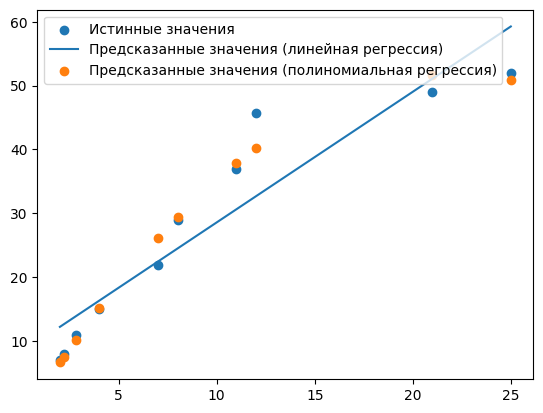

In [195]:
plt.scatter(X, y, label='Истинные значения');
plt.plot(X, lr.predict(X), label='Предсказанные значения (линейная регрессия)');
plt.scatter(X, lr2.predict(X_p), label='Предсказанные значения (полиномиальная регрессия)');
plt.legend();

Если у нас было бы несколько предикторов, то преобразование PolynomialFeatures позволило бы получить все возможные комбинации степеней. Кстати, никто не запрещает нам использовать полиномы более высоких степеней чем 2.

Теперь мы с вами знаем, как работает линейная и полиномиальная регрессия, умеем использовать регуляризации. <b>Поздравляю вас с началом вашего пути в ML!</b>